In [12]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic dataset for 5 Hubs (Distribution Centers)
hubs = pd.DataFrame({
    'Hub_ID': range(1, 6),
    'X': np.random.randint(0, 100, 5),
    'Y': np.random.randint(0, 100, 5),
    'Capacity': np.random.randint(200, 500, 5) # Capacity range: 200 - 500 units
})

# Generate synthetic dataset for 20 Demand Nodes (Delivery Locations)
nodes = pd.DataFrame({
    'Node_ID': range(1, 21),
    'X': np.random.randint(0, 100, 20),
    'Y': np.random.randint(0, 100, 20),
    'Demand': np.random.randint(10, 50, 20) # Demand range: 10 - 50 units
})

# Save to CSV files for GitHub repository
hubs.to_csv('hubs.csv', index=False)
nodes.to_csv('nodes.csv', index=False)

print("Synthetic logistics dataset created successfully!")
print("Hubs Sample:")
print(hubs.head())

Synthetic logistics dataset created successfully!
Hubs Sample:
   Hub_ID   X   Y  Capacity
0       1  51  20       287
1       2  92  82       299
2       3  14  86       351
3       4  71  74       330
4       5  60  74       349


# Problem Formulation: Constrained Logistics Network

The objective is to determine the optimal allocation matrix $x_{ij}$ (quantity of goods transported from hub $i$ to node $j$) to minimize total transportation cost while strictly satisfying hub capacity limits.

### Objective Function (Transportation Cost Minimization)
$$ \min \sum_{i=1}^{m} \sum_{j=1}^{n} c_{ij} x_{ij} $$

### Capacity Constraints
$$ \sum_{j=1}^{n} x_{ij} \leq C_{i} \quad \forall i \in \{1, \dots, m\} $$

Where:
- $m$: Number of hubs ($m = 5$)
- $n$: Number of demand nodes ($n = 20$)
- $c_{ij}$: Unit transportation cost based on Euclidean distance between hub $i$ and node $j$
- $C_i$: Maximum storage/handling capacity of hub $i$

In [15]:
import torch

def constraint_enforced_loss(X, cost_matrix, capacities, demands, penalty_weight=1000.0):
    """
    Computes total loss: Transport Cost + Capacity Penalty + Demand Violation Penalty.
    """
    # 1. Transportation cost
    transport_cost = torch.sum(X * cost_matrix)

    # 2. Capacity Constraint: Outflow <= Capacity
    hub_outflow = torch.sum(X, dim=1)
    capacity_violation = torch.relu(hub_outflow - capacities)

    # 3. Demand Constraint: Inflow >= Demand (Penalize under-delivery)
    node_inflow = torch.sum(X, dim=0)
    demand_violation = torch.relu(demands - node_inflow)

    # Total Penalty
    penalty = penalty_weight * (torch.sum(capacity_violation) + torch.sum(demand_violation))

    total_loss = transport_cost + penalty
    return total_loss, transport_cost, penalty

print("Updated Loss Function with Demand Constraint!")

Updated Loss Function with Demand Constraint!


In [16]:
import torch.optim as optim

# Convert data to PyTorch Tensors
hub_coords = torch.tensor(hubs[['X', 'Y']].values, dtype=torch.float32)
node_coords = torch.tensor(nodes[['X', 'Y']].values, dtype=torch.float32)
capacities = torch.tensor(hubs['Capacity'].values, dtype=torch.float32)
demands = torch.tensor(nodes['Demand'].values, dtype=torch.float32)

# Compute Euclidean Cost Matrix (m x n)
cost_matrix = torch.cdist(hub_coords, node_coords)

# Initialize decision variables X
X = torch.randn((5, 20), dtype=torch.float32, requires_grad=True)

optimizer = optim.Adam([X], lr=0.1)

print("Starting Corrected Optimization Loop...")
for epoch in range(1, 101):
    optimizer.zero_grad()

X_pos = torch.relu(X)

loss, cost, penalty = constraint_enforced_loss(X_pos, cost_matrix, capacities, demands, penalty_weight=100.0)
loss.backward()
optimizer.step()
if epoch % 20 == 0:
  print(f"Epoch {epoch:03d} | Total Loss: {loss.item():.2f} | Transport Cost: {cost.item():.2f} | Penalty: {penalty.item():.2f}")

Starting Corrected Optimization Loop...
Epoch 020 | Total Loss: 47926.05 | Transport Cost: 6743.26 | Penalty: 41182.79
Epoch 040 | Total Loss: 43752.89 | Transport Cost: 11142.33 | Penalty: 32610.55
Epoch 060 | Total Loss: 40461.95 | Transport Cost: 14128.50 | Penalty: 26333.45
Epoch 080 | Total Loss: 38029.29 | Transport Cost: 16382.11 | Penalty: 21647.18
Epoch 100 | Total Loss: 35946.93 | Transport Cost: 18417.74 | Penalty: 17529.19


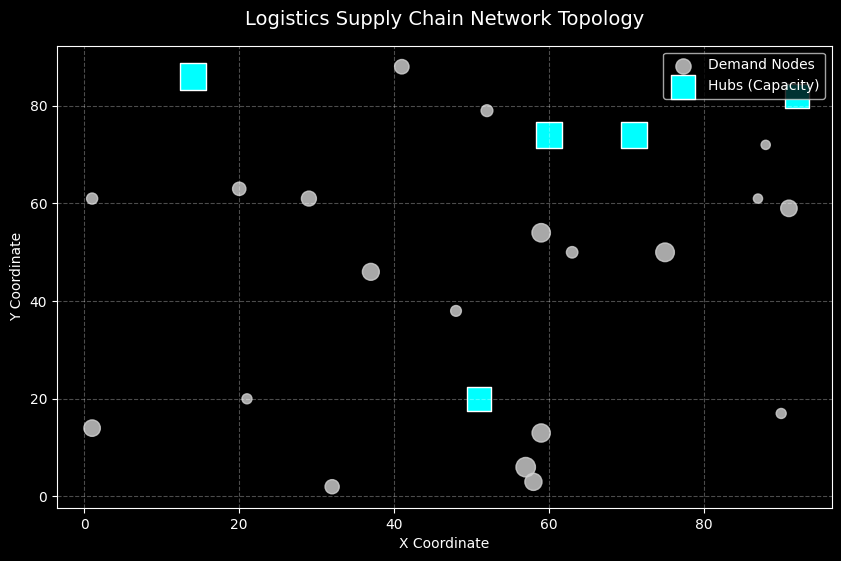

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.style.use('dark_background')

# Plot Demand Nodes
plt.scatter(nodes['X'], nodes['Y'], c='lightgray', s=nodes['Demand']*4, alpha=0.8, label='Demand Nodes')

# Plot Hubs
plt.scatter(hubs['X'], hubs['Y'], c='cyan', s=hubs['Capacity'], marker='s', edgecolors='white', label='Hubs (Capacity)')

plt.title("Logistics Supply Chain Network Topology", fontsize=14, pad=15)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()